In [81]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [82]:
df_train = pd.read_csv('data/train.csv')

In [83]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

In [84]:

df_train['Embarked']=df_train['Embarked'].fillna(df_train['Embarked'].mode())

In [85]:
df_train['Age']=df_train['Age'].astype(int)

In [86]:
df_train = df_train.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)

In [87]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\simoen\AppData\Local\Temp\ipykernel_9080\1220814546.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [88]:

df_train=pd.get_dummies(df_train,drop_first=True)

In [89]:
df_train['fare_bin'] = pd.qcut(df_train['Fare'], q=4, labels=False)

In [90]:
df_train['family']=df_train['SibSp']+df_train['Parch']

In [91]:
df_train['Age_bin'] = pd.qcut(df_train['Age'], q=4, labels=False)

In [92]:
df_train['Alone'] = (df_train['SibSp'] == 0)&(df_train['Parch'] == 0)

In [93]:
df_train['percent_workingclass1_survived'] = len(df_train[(df_train['Pclass']==1) & (df_train['Survived']==1)])/len(df_train[df_train['Pclass']==1])
df_train['percent_workingclass2_survived'] = len(df_train[(df_train['Pclass']==2) & (df_train['Survived']==1)])/len(df_train[df_train['Pclass']==2])
df_train['percent_workingclass3_survived'] = len(df_train[(df_train['Pclass']==3) & (df_train['Survived']==1)])/len(df_train[df_train['Pclass']==3])

In [94]:
df_train['percent_female_survived']=len(df_train[(df_train['Sex_male']==0) & (df_train['Survived']==1)])/len(df_train[df_train['Sex_male']==0])
df_train['percent_male_survived']=len(df_train[(df_train['Sex_male']==1) & (df_train['Survived']==1)])/len(df_train[df_train['Sex_male']==1])

In [95]:
Q1_age = df_train['Age'].quantile(0.25)
Q2_age = df_train['Age'].quantile(0.5)
Q3_age = df_train['Age'].quantile(0.75)
max_age = df_train['Age'].max()

In [96]:
df_train['age_Male_Survived_Q1'] = len(df_train[(df_train['Age']<=Q1_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Age']<=Q1_age) & (df_train['Sex_male'] == 1)])
df_train['age_Female_Survived_Q1'] = len(df_train[(df_train['Age']<=Q1_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Age']<=Q1_age) & (df_train['Sex_male'] == 0)])
df_train['age_Male_Survived_Q2'] = len(df_train[(df_train['Age']>Q1_age) & (df_train['Age']<=Q2_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Age']>Q1_age) & (df_train['Age']<=Q2_age) & (df_train['Sex_male'] == 1)])
df_train['age_Female_Survived_Q2'] = len(df_train[(df_train['Age']>Q1_age) & (df_train['Age']<=Q2_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Age']>Q1_age) & (df_train['Age']<=Q2_age) & (df_train['Sex_male'] == 0)])
df_train['age_Male_Survived_Q3'] = len(df_train[(df_train['Age']>Q2_age) & (df_train['Age']<=Q3_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Age']>Q2_age) & (df_train['Age']<=Q3_age) & (df_train['Sex_male'] == 1)])
df_train['age_Female_Survived_Q3'] = len(df_train[(df_train['Age']>Q2_age) & (df_train['Age']<=Q3_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Age']>Q2_age) & (df_train['Age']<=Q3_age) & (df_train['Sex_male'] == 0)])
df_train['age_Male_Survived_max'] = len(df_train[(df_train['Age']>Q3_age) & (df_train['Age']<=max_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Age']>Q3_age) & (df_train['Age']<=max_age) & (df_train['Sex_male'] == 1)])
df_train['age_Female_Survived_max'] = len(df_train[(df_train['Age']>Q3_age) & (df_train['Age']<=max_age) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Age']>Q3_age) & (df_train['Age']<=max_age) & (df_train['Sex_male'] == 0)])

In [97]:
Q1_fare = df_train['Fare'].quantile(0.25)
Q2_fare = df_train['Fare'].quantile(0.5)
Q3_fare = df_train['Fare'].quantile(0.75)
max_fare = df_train['Fare'].max()

In [98]:
df_train['fare_Male_Survived_Q1'] = len(df_train[(df_train['Fare']<=Q1_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Fare']<=Q1_fare) & (df_train['Sex_male'] == 1)])
df_train['fare_Female_Survived_Q1'] = len(df_train[(df_train['Fare']<=Q1_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Fare']<=Q1_fare) & (df_train['Sex_male'] == 0)])
df_train['fare_Male_Survived_Q2'] = len(df_train[(df_train['Fare']>Q1_fare) & (df_train['Fare']<=Q2_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Fare']>Q1_fare) & (df_train['Fare']<=Q2_fare) & (df_train['Sex_male'] == 1)])
df_train['fare_Female_Survived_Q2'] = len(df_train[(df_train['Fare']>Q1_fare) & (df_train['Fare']<=Q2_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Fare']>Q1_fare) & (df_train['Fare']<=Q2_fare) & (df_train['Sex_male'] == 0)])
df_train['fare_Male_Survived_Q3'] = len(df_train[(df_train['Fare']>Q2_fare) & (df_train['Fare']<=Q3_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Fare']>Q2_fare) & (df_train['Fare']<=Q3_fare) & (df_train['Sex_male'] == 1)])
df_train['fare_Female_Survived_Q3'] = len(df_train[(df_train['Fare']>Q2_fare) & (df_train['Fare']<=Q3_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Fare']>Q2_fare) & (df_train['Fare']<=Q3_fare) & (df_train['Sex_male'] == 0)])
df_train['fare_Male_Survived_max'] = len(df_train[(df_train['Fare']>Q3_fare) & (df_train['Fare']<=max_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 1)])/len(df_train[(df_train['Fare']>Q3_fare) & (df_train['Fare']<=max_fare) & (df_train['Sex_male'] == 1)])
df_train['fare_Female_Survived_max'] = len(df_train[(df_train['Fare']>Q3_fare) & (df_train['Fare']<=max_fare) & (df_train['Survived'] == 1)&(df_train['Sex_male'] == 0)])/len(df_train[(df_train['Fare']>Q3_fare) & (df_train['Fare']<=max_fare) & (df_train['Sex_male'] == 0)])

In [99]:
x_train = df_train.drop('Survived', axis=1)
y_train = df_train['Survived']
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,precision_score, recall_score
from sklearn.model_selection import GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

C:\Users\simoen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [16:45:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

XGBoost Confusion Matrix:
[[90 15]
 [20 54]]
XGBoost Accuracy: 0.8044692737430168
XGBoost F1 Score: 0.7552447552447552
XGBoost Precision Score: 0.782608695652174
XGBoost Recall Score: 0.7297297297297297


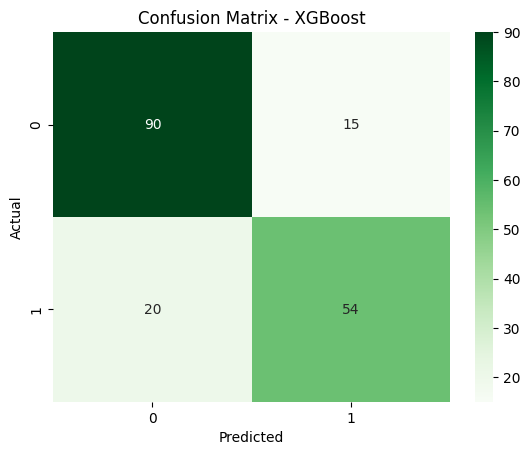

In [100]:
param_grid = {
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'n_estimators': [100, 200, 500, 1000],
        'max_depth': [3, 5, 7]
    }
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                              subsample=0.8, colsample_bytree=0.8, gamma=0.1, reg_alpha=0.1, reg_lambda=1)
grid_search = GridSearchCV(model_xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train_scaled, y_train)
model_xgb = grid_search.best_estimator_
y_pred_xgb = model_xgb.predict(x_test_scaled)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y_test, y_pred_xgb))
print("XGBoost Precision Score:", precision_score(y_test, y_pred_xgb))
print("XGBoost Recall Score:", recall_score(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [101]:
df_test = pd.read_csv('data/test.csv')

In [102]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].mean())
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())
df_test['Embarked']=df_test['Embarked'].fillna(df_test['Embarked'].mode())
df_test['Age']=df_test['Age'].astype(int)
df_test = df_test.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
C:\Users\simoen\AppData\Local\Temp\ipykernel_9080\3383282570.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [103]:
df_test=pd.get_dummies(df_test,drop_first=True)
df_test['fare_bin'] = pd.qcut(df_test['Fare'], q=4, labels=False)
df_test['family']=df_test['SibSp']+df_test['Parch']
df_test['Age_bin'] = pd.qcut(df_test['Age'], q=4, labels=False)
df_test['Alone'] = (df_test['SibSp'] == 0)&(df_test['Parch'] == 0)

In [104]:
df = df_test.reindex(columns=x_train.columns, fill_value=0)
df_test_scaled = scaler.transform(df)
predictions = model_xgb.predict(df_test_scaled)
submission = pd.DataFrame({
    'PassengerId':pd.read_csv('data/test.csv')['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)

In [105]:
check_submission = pd.read_csv('submission.csv')
check_submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
